In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

cwd = os.getcwd()
root = os.path.dirname(cwd) if cwd.endswith('/code') else cwd

df = pd.read_csv(root + '/artifacts/results_grid.csv')

traj = (
    df.groupby(['model_id', 'checkpoint_idx'], as_index=False)
      .agg(
          n_params=('n_params', 'mean'),
          train_tokens_real=('train_tokens_real', 'mean'),
          val_loss=('val_loss', 'mean'),
          val_loss_std=('val_loss', 'std'),
          mu=('mu_landscape', 'mean'),
          mu_std=('mu_landscape', 'std'),
      )
)
traj['mu'] = np.clip(traj['mu'].to_numpy(), 1e-12, None)
traj['val_loss_std'] = traj['val_loss_std'].fillna(0.0)
traj['mu_std'] = traj['mu_std'].fillna(0.0)

In [2]:
all_ids = sorted(traj['model_id'].unique())

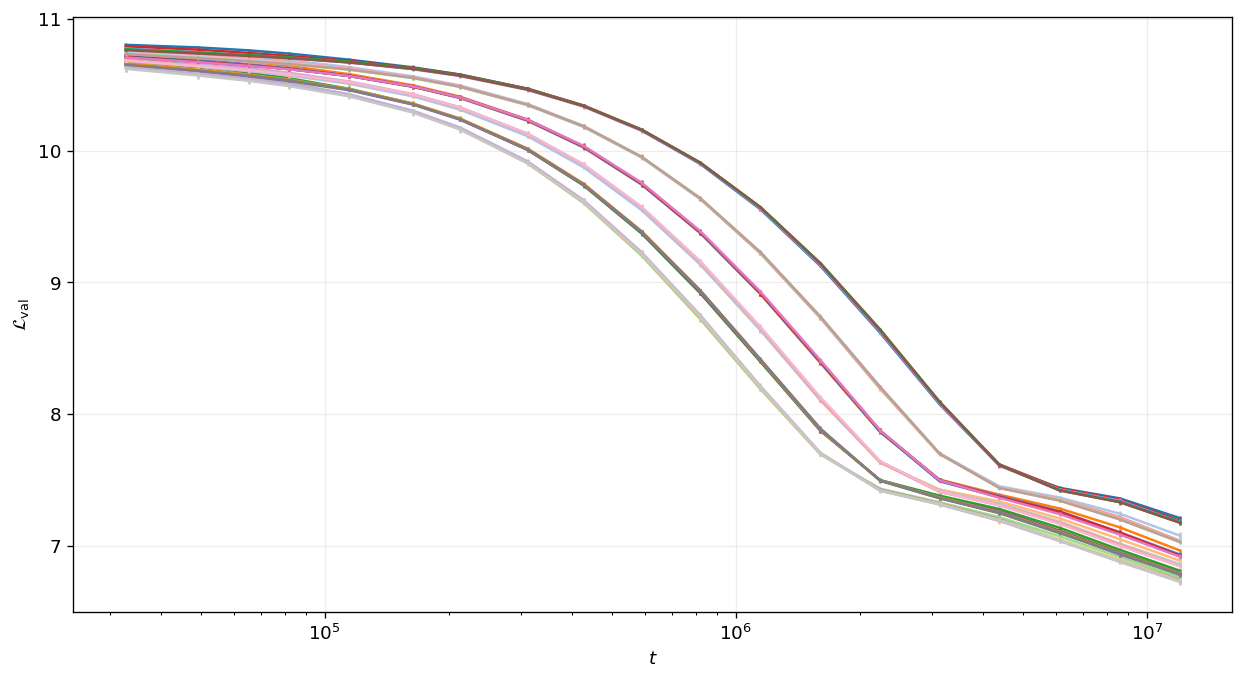

In [3]:
palette = plt.get_cmap('tab20').colors

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for i, model_id in enumerate(all_ids):
    g = traj[traj['model_id'] == model_id].sort_values('train_tokens_real')
    color = palette[i % len(palette)]
    ax.plot(g['train_tokens_real'], g['val_loss'], '-', color=color)
    ax.errorbar(g['train_tokens_real'], g['val_loss'], yerr=g['val_loss_std'], fmt='none', ecolor=color)

ax.set_xscale('log')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\mathcal{L}_{\mathrm{val}}$')
ax.grid(True, alpha=0.22)
fig.tight_layout()

out_path = root + '/paper/figures/fig_loss_all_models.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')

plt.show()

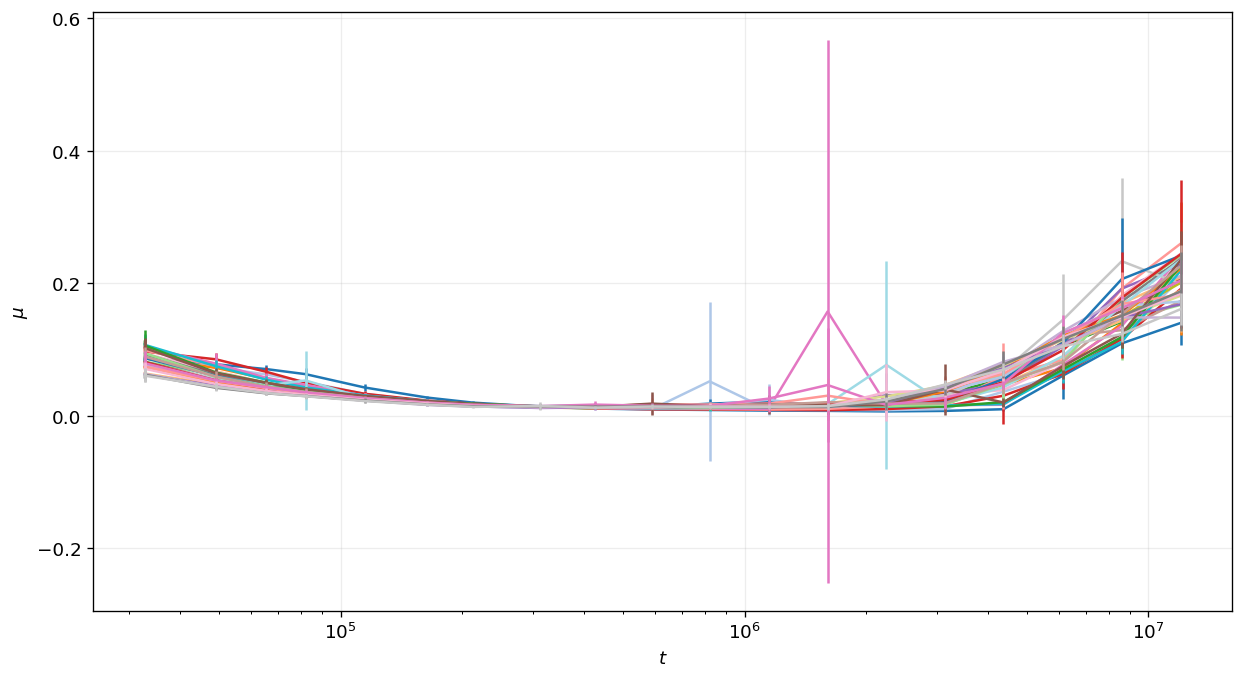

In [4]:
palette = plt.get_cmap('tab20').colors

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for i, model_id in enumerate(all_ids):
    g = traj[traj['model_id'] == model_id].sort_values('train_tokens_real')
    color = palette[i % len(palette)]
    ax.plot(g['train_tokens_real'], g['mu'], '-', color=color)
    ax.errorbar(g['train_tokens_real'], g['mu'], yerr=g['mu_std'], fmt='none', ecolor=color)

ax.set_xscale('log')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\mu$')
ax.grid(True, alpha=0.22)
fig.tight_layout()

out_path = root + '/paper/figures/fig_mu_all_models.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')

plt.show()